# Surya OCR Testing

**WeatherSpeak PH** — Gemma 4 Hackathon

## About Surya OCR

[Surya](https://github.com/VikParuchuri/surya) is a modern AI-native OCR toolkit that:
- Supports **90+ languages**
- **Beats Google Cloud Vision** on benchmarks
- Includes layout analysis, table recognition, reading order detection
- Purpose-built for **document understanding** (not scene text)
- 19.6k stars, actively maintained

### Why Test Surya?
Surya represents the current **state-of-the-art in open-source document OCR**. If it performs well on PAGASA bulletins, it's a strong production candidate.

## 1. Install Surya OCR

In [ ]:
! pip install --upgrade pip

In [ ]:
! pip install torch torchvision surya-ocr requests pillow tqdm



In [1]:
! pip install "transformers==4.56.2"

  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 8.9 MB/s  0:00:01m0:00:010:01
Using cached huggingface_hub-0.36.2-py3-none-any.whl (566 kB)
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.10.1
    Uninstalling huggingface_hub-1.10.1:
      Successfully uninstalled huggingface_hub-1.10.1
  Attempting uninstall: transformers━━━━━━━━━━━━ 0/2 [huggingface-hub]
    Found existing installation: transformers 5.5.332m0/2 [huggingface-hub]
    Uninstalling transformers-5.5.3:m╺━━━━━━━━━━━━━━━━━━━ 1/2 [transformers]
      Successfully uninstalled transformers-5.5.3━━━━━━━━━━━━━━━━━ 1/2 [transformers]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [transformers] [transformers]


In [2]:
import os
import json
from pathlib import Path
from PIL import Image
import time

# surya 0.17.x API — predictor-based
from surya.recognition import RecognitionPredictor
from surya.detection import DetectionPredictor
from surya.foundation import FoundationPredictor

print("✓ Surya OCR imported successfully")

/Users/josereyes/Dev/gemma4-hackathon/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Surya OCR imported successfully


## 2. Load Sample Data

Load the sample images prepared in the setup notebook.

In [3]:
# Load metadata
data_dir = Path("../data")
metadata_path = data_dir / "sample_metadata.json"

with open(metadata_path, 'r') as f:
    metadata = json.load(f)

samples = metadata['samples']
print(f"Loaded {len(samples)} sample images")

# Create output directory for results
output_dir = data_dir / "surya_results"
output_dir.mkdir(exist_ok=True)

Loaded 10 sample images


## 3. Initialize Surya Models

Surya uses separate models for detection and recognition.

In [4]:
%%time
print("Loading Surya models (downloads on first run, cached thereafter)...")

foundation_predictor = FoundationPredictor()
det_predictor = DetectionPredictor()
rec_predictor = RecognitionPredictor(foundation_predictor)

print("✓ Models loaded")

Loading Surya models (downloads on first run, cached thereafter)...
✓ Models loaded
CPU times: user 136 ms, sys: 398 ms, total: 535 ms
Wall time: 2.77 s


## 4. Run OCR on Sample Images

Process each sample image and extract text.

In [5]:
results = []

for i, sample in enumerate(samples, 1):
    print(f"\n{'='*60}")
    print(f"Processing {i}/{len(samples)}: {sample['filename']}")
    print(f"{'='*60}")

    # Load image
    image = Image.open(sample['image_path'])

    # Run OCR — surya 0.17.x API
    start_time = time.time()
    predictions = rec_predictor([image], det_predictor=det_predictor)
    processing_time = time.time() - start_time

    # Extract text from predictions
    prediction = predictions[0]
    text_lines = prediction.text_lines  # list of TextLine objects
    full_text = '\n'.join([line.text for line in text_lines])

    # Serialisable form for JSON
    text_lines_data = [
        {"text": line.text, "confidence": line.confidence}
        for line in text_lines
    ]

    # Store results
    result = {
        'filename': sample['filename'],
        'storm': sample['storm'],
        'processing_time': processing_time,
        'num_lines': len(text_lines),
        'full_text': full_text,
        'text_lines': text_lines_data
    }
    results.append(result)

    # Display summary
    print(f"\n📊 Results:")
    print(f"  Processing time: {processing_time:.2f}s")
    print(f"  Lines detected: {len(text_lines)}")
    print(f"  Characters extracted: {len(full_text)}")
    print(f"\n📄 Extracted text (first 500 characters):")
    print("-" * 60)
    print(full_text[:500])
    print("-" * 60)


Processing 1/10: PAGASA_20-19W_Pepito_SWB#01.pdf


Recognizing Text: 100%|██████████| 115/115 [00:51<00:00,  2.24it/s]



📊 Results:
  Processing time: 54.13s
  Lines detected: 115
  Characters extracted: 4800

📄 Extracted text (first 500 characters):
------------------------------------------------------------
Republic of the Philippines
Management
System
DEPARTMENT OF SCIENCE AND TECHNOLOGY
ISO 9001:2015
Philippine Atmospheric, Geophysical and Astronomical
Services Administration (PAGASA)
TUVRheinland
Weather Division
www.tuv.com
CERTIFIED
ID 9105085309
<b>SEVERE WEATHER BULLETIN #1</b>
FOR: TROPICAL DEPRESSION "PEPITO"
TROPICAL CYCLONE: ALERT
<b>ISSUED AT 5:00 AM, 19 October 2020</b>
(Valid for broadcast until the next bulletin to be issued at 11 AM today)
THE LOW PRESSURE AREA EAST OF CATANDUANES H
------------------------------------------------------------

Processing 2/10: PAGASA_20-19W_Pepito_SWB#02.pdf


Recognizing Text: 100%|██████████| 124/124 [00:34<00:00,  3.58it/s]



📊 Results:
  Processing time: 35.74s
  Lines detected: 124
  Characters extracted: 4637

📄 Extracted text (first 500 characters):
------------------------------------------------------------
Republic of the Philippines
Management
System
DEPARTMENT OF SCIENCE AND TECHNOLOGY
ISO 9001:2015
Philippine Atmospheric, Geophysical and Astronomical
Services Administration (PAGASA)
<b>TÜV</b>Rheinland
Weather Division
CERTIFIED
www.tuv.com
ID 9105085309
<b>SEVERE WEATHER BULLETIN #2</b>
FOR: TROPICAL DEPRESSION "PEPITO"
TROPICAL CYCLONE: WARNING
<b>ISSUED AT 11:00 AM, 19 October 2020</b>
(Valid for broadcast until the next bulletin to be issued at 5 PM today)
TROPICAL DEPRESSION "PEPITO" ACCEL
------------------------------------------------------------

Processing 3/10: PAGASA_22-TC02_Basyang_TCA#01.pdf


...


📊 Results:
  Processing time: 27.89s
  Lines detected: 176
  Characters extracted: 3082

📄 Extracted text (first 500 characters):
------------------------------------------------------------
MMSS-05 Rev.1 / 24-06-2024
Republic of the Philippines
Management
System
DEPARTMENT OF SCIENCE AND TECHNOLOGY
ISO 9001:2015
Philippine Atmospheric, Geophysical and Astronomical
TÜVRheinland
Services Administration (PAGASA)
CERTIFIED
www.tuv.com
Weather Division
ID 9105085309
BAGONG PILIPINAS
TROPICAL CYCLONE ADVISORY NR. 3
Tropical Storm DANAS (Formerly "BISING")
Issued at 11:00 AM, 05 July 2025
Valid for broadcast until the next bulletin at 11:00 PM today.
"DANAS" IS SLOWLY TURNING EAST NORTHEA
------------------------------------------------------------

Processing 9/10: PAGASA_26-TC02_Basyang_TCB#01.pdf


Recognizing Text: 100%|██████████| 171/171 [00:31<00:00,  5.45it/s]



📊 Results:
  Processing time: 31.84s
  Lines detected: 171
  Characters extracted: 3056

📄 Extracted text (first 500 characters):
------------------------------------------------------------
MMSS-04 Rev.1 / 24-06-2024
Republic of the Philippines
Management
System
DEPARTMENT OF SCIENCE AND TECHNOLOGY
ISO 9001:2015
Philippine Atmospheric, Geophysical and Astronomical
TÜVRheinland
Services Administration (PAGASA)
CERTIFIED
www.tuv.com
Weather Division
ID 9105085309
BAGONG PILIPINAS
TROPICAL CYCLONE BULLETIN NR. 1
<b>Tropical Depression BASYANG</b>
Issued at 11:00 PM, 03 February 2026
Valid for broadcast until the next bulletin at 5:00 AM tomorrow.
THE TROPICAL DEPRESSION HAS ENTERED TH
------------------------------------------------------------

Processing 10/10: PAGASA_26-TC02_Basyang_TCB#02.pdf


Recognizing Text: 100%|██████████| 162/162 [00:30<00:00,  5.40it/s]


📊 Results:
  Processing time: 30.56s
  Lines detected: 162
  Characters extracted: 2810

📄 Extracted text (first 500 characters):
------------------------------------------------------------
MMSS-04 Rev.1 / 24-06-2024
Republic of the Philippines
Management
System
DEPARTMENT OF SCIENCE AND TECHNOLOGY
ISO 9001:2015
Philippine Atmospheric, Geophysical and Astronomical
TÜVRheinland
Services Administration (PAGASA)
CERTIFIED
www.tuv.com
Weather Division
ID 9105085309
BAGONG PILIPINAS
TROPICAL CYCLONE BULLETIN NR. 2
Tropical Depression BASYANG
Issued at 5:00 AM, 04 February 2026
Valid for broadcast until the next bulletin at 11:00 AM today.
BASYANG ACCELERATES WEST SOUTHWESTWARD WHILE MAI
------------------------------------------------------------


## 5. Save Results

Save OCR results for comparison in the analysis notebook.

In [6]:
# Save results to JSON
results_path = output_dir / "surya_ocr_results.json"
with open(results_path, 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print(f"✓ Results saved to: {results_path}")

# Also save full text files for easy reading
for result in results:
    text_path = output_dir / f"{Path(result['filename']).stem}_text.txt"
    with open(text_path, 'w', encoding='utf-8') as f:
        f.write(result['full_text'])

print(f"✓ Text files saved to: {output_dir}")

✓ Results saved to: ../data/surya_results/surya_ocr_results.json
✓ Text files saved to: ../data/surya_results


## 6. Performance Summary

Aggregate performance metrics across all samples.

In [7]:
import statistics

processing_times = [r['processing_time'] for r in results]
line_counts = [r['num_lines'] for r in results]

print("\n" + "="*60)
print("SURYA OCR PERFORMANCE SUMMARY")
print("="*60)
print(f"\n📊 Processing Time:")
print(f"  Average: {statistics.mean(processing_times):.2f}s")
print(f"  Min: {min(processing_times):.2f}s")
print(f"  Max: {max(processing_times):.2f}s")
print(f"\n📄 Content:")
print(f"  Average lines per page: {statistics.mean(line_counts):.0f}")
print(f"  Total samples processed: {len(results)}")
print(f"\n✓ All results saved to: {output_dir.absolute()}")


SURYA OCR PERFORMANCE SUMMARY

📊 Processing Time:
  Average: 32.23s
  Min: 24.89s
  Max: 54.13s

📄 Content:
  Average lines per page: 161
  Total samples processed: 10

✓ All results saved to: /Users/josereyes/Dev/gemma4-hackathon/notebooks/../data/surya_results


## 7. Visual Inspection

Display one sample with its extracted text for manual quality assessment.

Sample: PAGASA_20-19W_Pepito_SWB#01.pdf
Storm: pagasa-20-19W



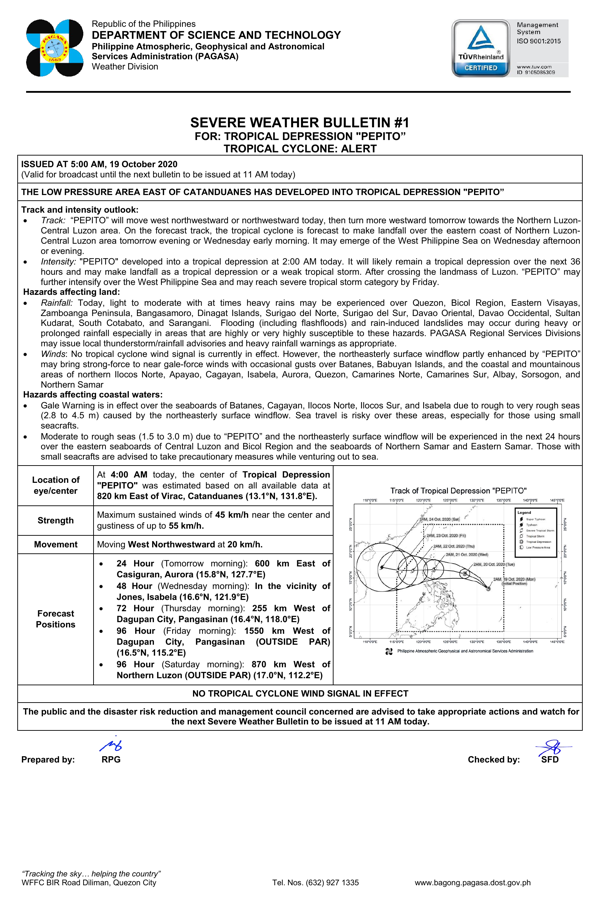


📄 EXTRACTED TEXT:
Republic of the Philippines
Management
System
DEPARTMENT OF SCIENCE AND TECHNOLOGY
ISO 9001:2015
Philippine Atmospheric, Geophysical and Astronomical
Services Administration (PAGASA)
TUVRheinland
Weather Division
www.tuv.com
CERTIFIED
ID 9105085309
<b>SEVERE WEATHER BULLETIN #1</b>
FOR: TROPICAL DEPRESSION "PEPITO"
TROPICAL CYCLONE: ALERT
<b>ISSUED AT 5:00 AM, 19 October 2020</b>
(Valid for broadcast until the next bulletin to be issued at 11 AM today)
THE LOW PRESSURE AREA EAST OF CATANDUANES HAS DEVELOPED INTO TROPICAL DEPRESSION "PEPITO"
Track and intensity outlook:
Track: "PEPITO" will move west northwestward or northwestward today, then turn more westward tomorrow towards the Northern Luzon-
Central Luzon area. On the forecast track, the tropical cyclone is forecast to make landfall over the eastern coast of Northern Luzon-
Central Luzon area tomorrow evening or Wednesday early morning. It may emerge of the West Philippine Sea on Wednesday afternoon
or evening.


In [8]:
# Display first sample
if results:
    sample_result = results[0]
    sample_info = samples[0]
    
    print(f"Sample: {sample_result['filename']}")
    print(f"Storm: {sample_result['storm']}")
    print(f"\n" + "="*60)
    
    # Show image
    img = Image.open(sample_info['image_path'])
    display(img.resize((600, int(600 * img.size[1] / img.size[0]))))
    
    # Show extracted text
    print("\n📄 EXTRACTED TEXT:")
    print("="*60)
    print(sample_result['full_text'])
    print("="*60)

## 8. Preliminary Assessment

### ✅ Strengths
- Modern AI-native approach
- Good multilingual support
- Active development and maintenance
- Built-in layout analysis

### ❓ Questions for Comparison
- How does accuracy compare to Marker?
- Can Gemma 4 Vision match this accuracy?
- Is the processing speed acceptable for production?
- How well does it handle tables and coordinates?

### 📝 Next Steps
Proceed to **Notebook 03** to test Marker on the same samples for comparison.